<a href="https://colab.research.google.com/github/fatemabasher-lab/Predictive-Analytics-in-Business---MIS444/blob/main/Predictive_Analytics_in_Business_MIS444.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Upload the zip file
from google.colab import files
uploaded = files.upload()  # click "Choose Files" and select the zip you downloaded

Saving archive.zip to archive.zip


In [ ]:
# Cell 2: Unzip
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

!ls   # confirm you now see Walmart.csv listed

archive.zip  sample_data  Walmart.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Load data
df = pd.read_csv('Walmart.csv')
print("Shape:", df.shape)
df.head()

Shape: (6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [ ]:
df.describe()


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [ ]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [ ]:
# Duplicates
print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()



Duplicate rows: 0


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['DayOfWeek'] = df['Date'].dt.dayofweek

df.sort_values('Date', inplace=True)
df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,WeekOfYear,DayOfWeek
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,4
1287,10,2010-02-05,2193048.75,0,54.34,2.962,126.442065,9.765,2010,2,5,4
5148,37,2010-02-05,536006.73,0,45.97,2.572,209.852966,8.554,2010,2,5,4
2288,17,2010-02-05,789036.02,0,23.11,2.666,126.442065,6.548,2010,2,5,4
4147,30,2010-02-05,465108.52,0,39.05,2.572,210.752605,8.324,2010,2,5,4


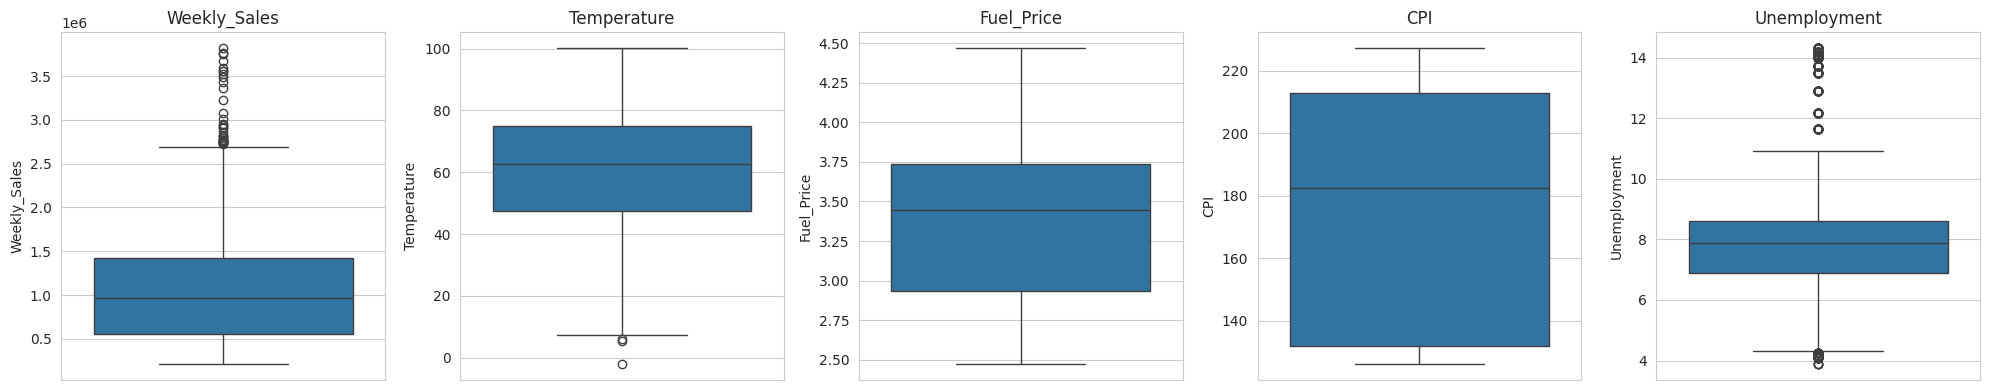

In [ ]:
numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [ ]:
def iqr_outlier_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

for col in numeric_cols:
    low, high = iqr_outlier_bounds(df[col])
    n_outliers = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col}: {n_outliers} outliers outside [{low:.2f}, {high:.2f}]")


Weekly_Sales: 34 outliers outside [-746862.73, 2720371.49]
Temperature: 3 outliers outside [6.24, 116.16]
Fuel_Price: 0 outliers outside [1.73, 4.94]
CPI: 0 outliers outside [10.22, 334.26]
Unemployment: 481 outliers outside [4.29, 11.22]


In [ ]:
from sklearn.preprocessing import StandardScaler

# One-hot encode Store (categorical identifier, not ordinal)
df_encoded = pd.get_dummies(df, columns=['Store'], prefix='Store', drop_first=True)

# Columns to scale
scale_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

scaler = StandardScaler()
df_encoded[scale_cols] = scaler.fit_transform(df_encoded[scale_cols])

df_encoded.head()


,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,WeekOfYear,DayOfWeek,Store_2,Store_3,Store_4,Store_5,Store_6,Store_7,Store_8,Store_9,Store_10,Store_11,Store_12,Store_13,Store_14,Store_15,Store_16,Store_17,Store_18,Store_19,Store_20,Store_21,Store_22,Store_23,Store_24,Store_25,Store_26,Store_27,Store_28,Store_29,Store_30,Store_31,Store_32,Store_33,Store_34,Store_35,Store_36,Store_37,Store_38,Store_39,Store_40,Store_41,Store_42,Store_43,Store_44,Store_45
0,2010-02-05,1643690.90,0,-0.995136,-1.713800,1.004175,0.056964,2010,2,5,4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1287,2010-02-05,2193048.75,0,-0.342873,-0.864097,-1.146941,0.941415,2010,2,5,4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5148,2010-02-05,536006.73,0,-0.796692,-1.713800,0.972580,0.295803,2010,2,5,4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
2288,2010-02-05,789036.02,0,-2.036153,-1.509000,-1.146941,-0.773642,2010,2,5,4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4147,2010-02-05,465108.52,0,-1.171892,-1.713800,0.995440,0.173185,2010,2,5,4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


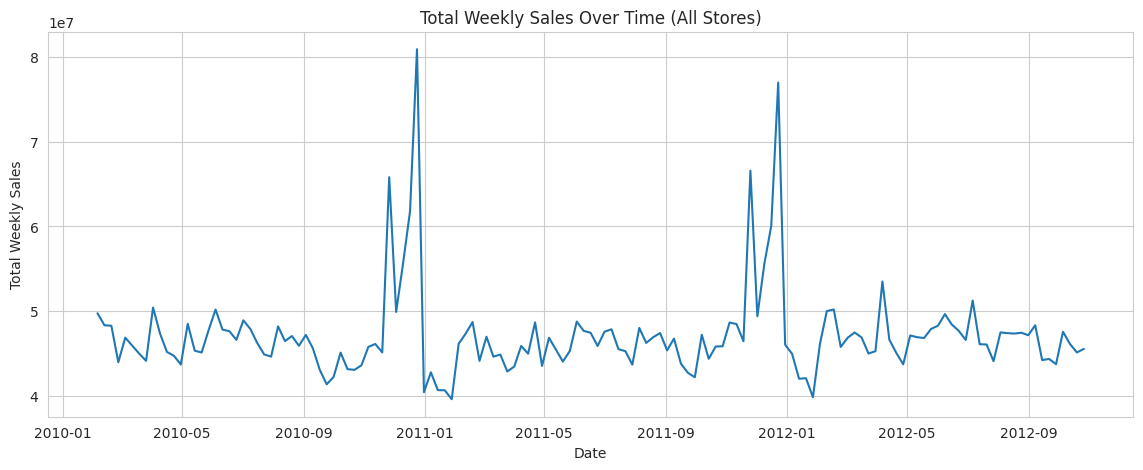

In [ ]:
weekly = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
plt.figure(figsize=(14,5))
plt.plot(weekly['Date'], weekly['Weekly_Sales'])
plt.title('Total Weekly Sales Over Time (All Stores)')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.show()


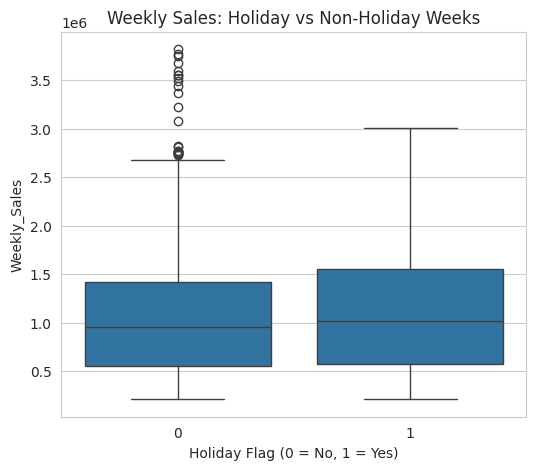

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64


In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df)
plt.title('Weekly Sales: Holiday vs Non-Holiday Weeks')
plt.xlabel('Holiday Flag (0 = No, 1 = Yes)')
plt.show()

print(df.groupby('Holiday_Flag')['Weekly_Sales'].mean())


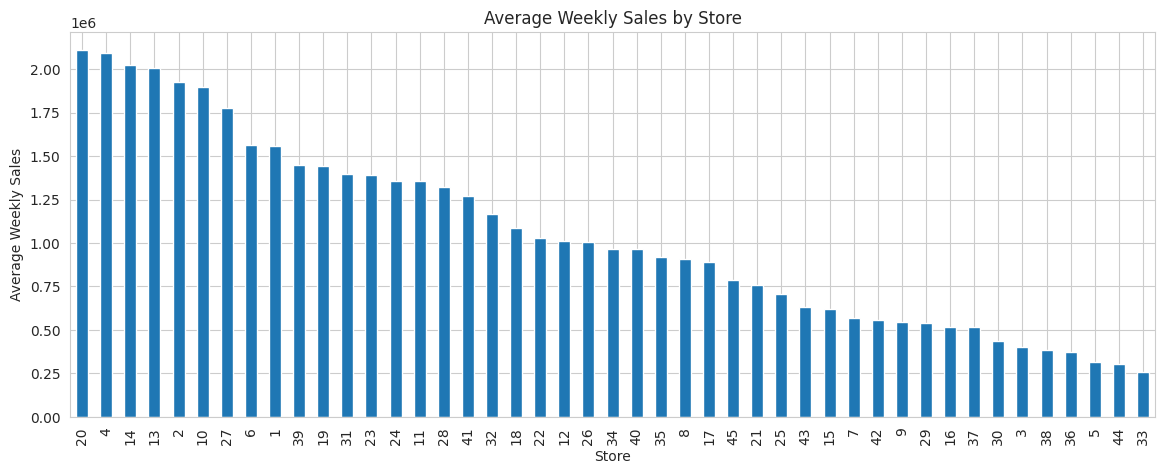

In [ ]:
store_avg = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)
plt.figure(figsize=(14,5))
store_avg.plot(kind='bar')
plt.title('Average Weekly Sales by Store')
plt.xlabel('Store')
plt.ylabel('Average Weekly Sales')
plt.show()


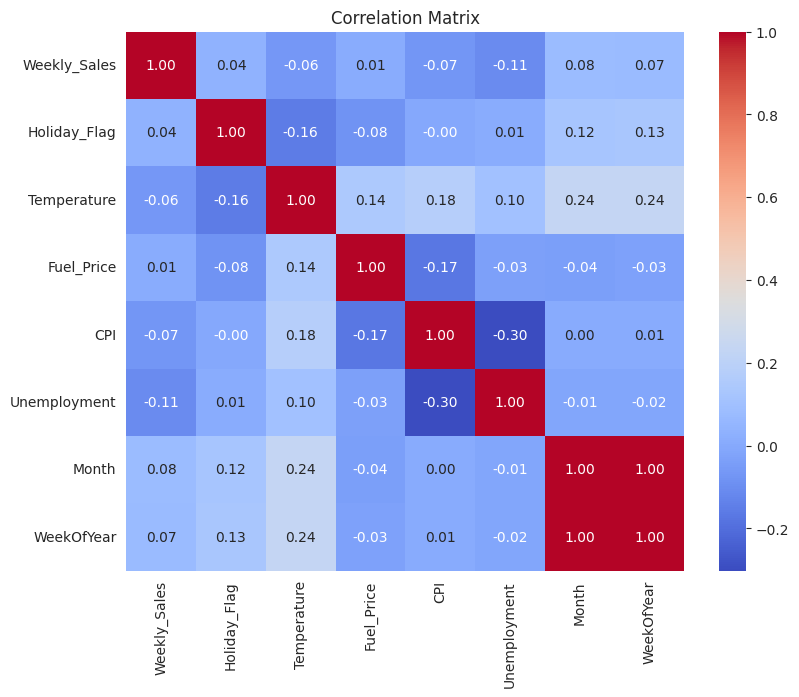

In [ ]:
corr_cols = ['Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'WeekOfYear']
plt.figure(figsize=(9,7))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


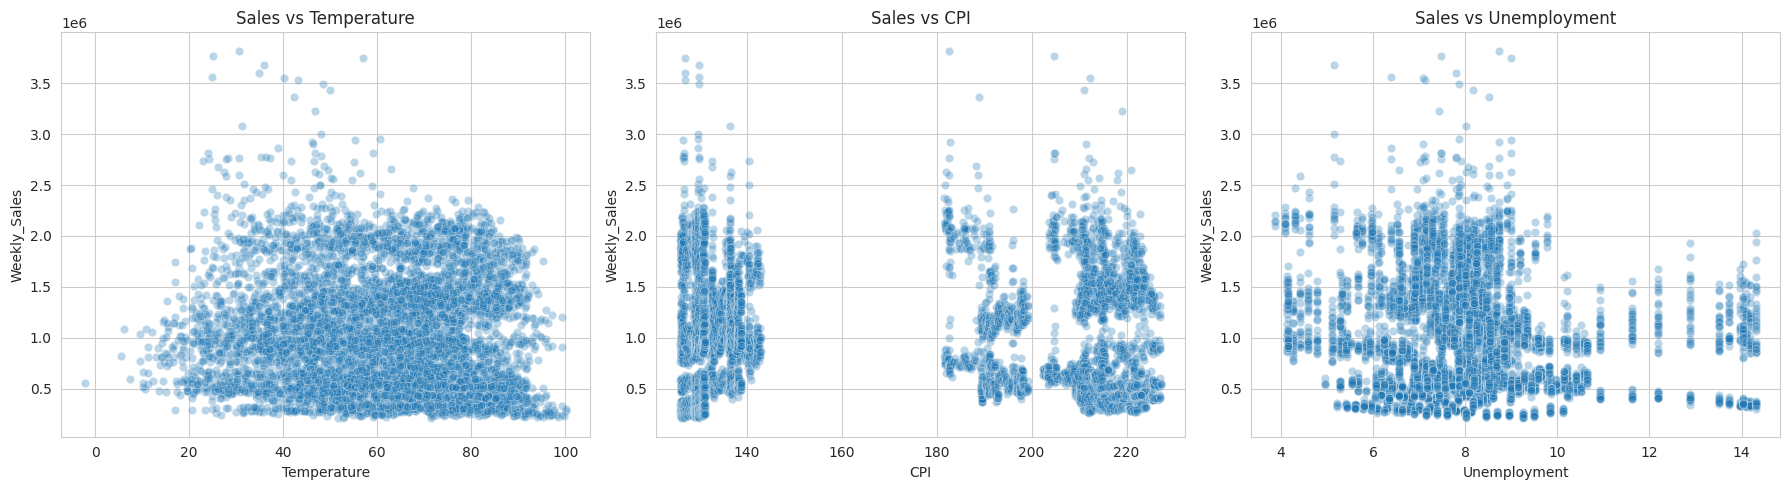

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df, ax=axes[0], alpha=0.3)
sns.scatterplot(x='CPI', y='Weekly_Sales', data=df, ax=axes[1], alpha=0.3)
sns.scatterplot(x='Unemployment', y='Weekly_Sales', data=df, ax=axes[2], alpha=0.3)
axes[0].set_title('Sales vs Temperature')
axes[1].set_title('Sales vs CPI')
axes[2].set_title('Sales vs Unemployment')
plt.tight_layout()
plt.show()


In [ ]:
target_corr = df[corr_cols].corr()['Weekly_Sales'].drop('Weekly_Sales').sort_values(key=abs, ascending=False)
print("Correlation with Weekly_Sales:")
print(target_corr)

Correlation with Weekly_Sales:
Unemployment   -0.106176
Month           0.076143
WeekOfYear      0.074211
CPI            -0.072634
Temperature    -0.063810
Holiday_Flag    0.036891
Fuel_Price      0.009464
Name: Weekly_Sales, dtype: float64


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_features = ['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'WeekOfYear']
X_vif = df[vif_features].copy()

vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))


        feature         VIF
5         Month  595.378473
6    WeekOfYear  525.081389
2    Fuel_Price   26.095257
4  Unemployment   15.503807
3           CPI   15.116941
1   Temperature   14.459035
0  Holiday_Flag    1.139798


In [ ]:
feature_cols = [c for c in df_encoded.columns if c.startswith('Store_')] + \
    ['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'WeekOfYear']

X = df_encoded[feature_cols]
y = df_encoded['Weekly_Sales']

print("Final feature matrix shape:", X.shape)


Final feature matrix shape: (6435, 50)


In [ ]:
df_encoded_sorted = df_encoded.sort_values('Date')
split_idx = int(len(df_encoded_sorted) * 0.8)

X_sorted = df_encoded_sorted[feature_cols]
y_sorted = df_encoded_sorted['Weekly_Sales']

X_train, X_test = X_sorted.iloc[:split_idx], X_sorted.iloc[split_idx:]
y_train, y_test = y_sorted.iloc[:split_idx], y_sorted.iloc[split_idx:]

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (5148, 50)  Test size: (1287, 50)


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=200),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)

    results.append({'Model': name, 'MAE': mae, 'MAPE': mape, 'MSE': mse, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
results_df


,Model,MAE,MAPE,MSE,RMSE,R2
0,Linear Regression,84398.272192,0.095770,1.370205e+10,117055.759938,0.951884
1,Ridge Regression,87064.143562,0.101580,1.429258e+10,119551.581341,0.949810
3,Random Forest,88602.812733,0.090765,1.889414e+10,137455.967105,0.933652
4,Gradient Boosting,182783.833799,0.242036,4.580787e+10,214027.740220,0.839142
2,Decision Tree,138785.483186,0.130372,5.210251e+10,228259.735439,0.817038


In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV MAE:", -grid_search.best_score_)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV MAE: 109426.2565009091


In [ ]:
best_rf = grid_search.best_estimator_
preds_tuned = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, preds_tuned)
mape = mean_absolute_percentage_error(y_test, preds_tuned)
mse = mean_squared_error(y_test, preds_tuned)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds_tuned)

tuned_result = {'Model': 'Random Forest (Tuned)', 'MAE': mae, 'MAPE': mape, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
print(tuned_result)

results_df = pd.concat([results_df, pd.DataFrame([tuned_result])], ignore_index=True)
results_df.sort_values('R2', ascending=False)


{'Model': 'Random Forest (Tuned)', 'MAE': 88161.61696410253, 'MAPE': 0.08952327224949212, 'MSE': 18662539117.74584, 'RMSE': np.float64(136610.90409533874), 'R2': 0.9344649324130563}


,Model,MAE,MAPE,MSE,RMSE,R2
0,Linear Regression,84398.272192,0.095770,1.370205e+10,117055.759938,0.951884
1,Ridge Regression,87064.143562,0.101580,1.429258e+10,119551.581341,0.949810
5,Random Forest (Tuned),88161.616964,0.089523,1.866254e+10,136610.904095,0.934465
2,Random Forest,88602.812733,0.090765,1.889414e+10,137455.967105,0.933652
3,Gradient Boosting,182783.833799,0.242036,4.580787e+10,214027.740220,0.839142
4,Decision Tree,138785.483186,0.130372,5.210251e+10,228259.735439,0.817038


Best model: Linear Regression


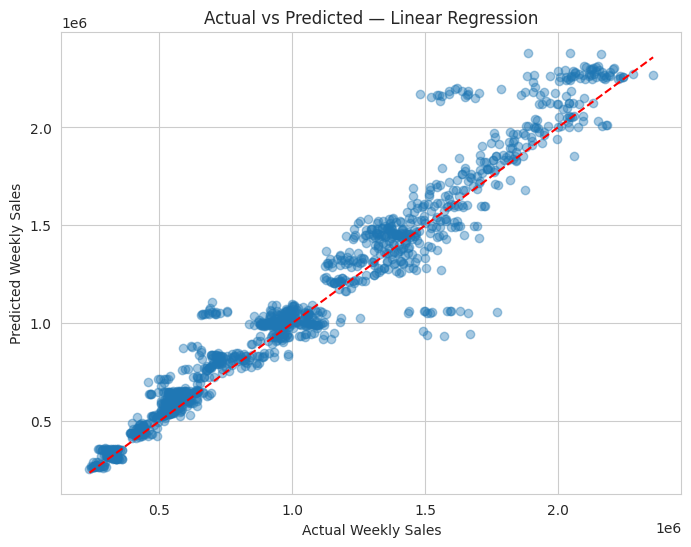

In [ ]:
best_model_name = results_df.sort_values('R2', ascending=False).iloc[0]['Model']
print("Best model:", best_model_name)

plt.figure(figsize=(8,6))
plt.scatter(y_test, preds_tuned, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Weekly Sales')
plt.ylabel('Predicted Weekly Sales')
plt.title(f'Actual vs Predicted — {best_model_name}')
plt.show()


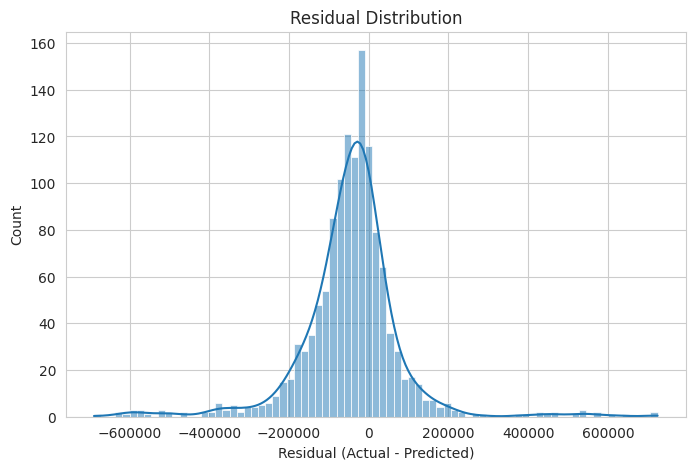

In [ ]:
residuals = y_test - preds_tuned
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.xlabel('Residual (Actual - Predicted)')
plt.show()


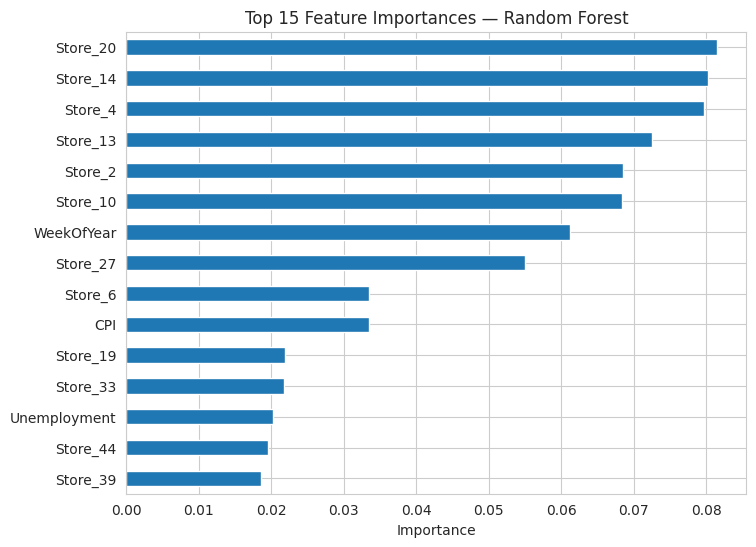

,0
Store_20,0.081490
Store_14,0.080310
Store_4,0.079715
Store_13,0.072598
Store_2,0.068501
Store_10,0.068472
WeekOfYear,0.061227
Store_27,0.055081
Store_6,0.033551
CPI,0.033445


In [ ]:
importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
top_n = 15
plt.figure(figsize=(8,6))
importances.head(top_n).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.show()

importances.head(top_n)
